**The story:** You've just joined the analytics team at **Olist**, Brazil's largest e-commerce marketplace.  
Your manager drops 9 CSV files on your desk and says: *"Give me a business review by Friday."*  
This notebook is that Friday review — built from scratch.

**What you'll learn:**
| Section | Skill | Industry Use |
|---|---|---|
| 1 | Loading & inspecting data | Every analytics project starts here |
| 2 | Cleaning & fixing dtypes | ~60% of real analyst time |
| 3 | Merging multi-table data | Joining facts to dimensions |
| 4 | GroupBy & aggregations | Business KPIs |
| 5 | Time series analysis | Trend detection |
| 6 | Customer segmentation (RFM) | Marketing analytics |
| 7 | Matplotlib visualizations | Charts for reports |
| 8 | Seaborn statistical plots | Distribution & relationship analysis |
| 9 | A complete business dashboard | Putting it all together |

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Consistent style throughout
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 4)})

DATA = Path('./data/')
print('Libraries loaded. Pandas:', pd.__version__)

Libraries loaded. Pandas: 2.2.2


---
## Section 1 — Loading & First Inspection
> **Analyst mindset:** Never trust a file you haven't profiled.

In [4]:
# Load the key tables
orders   = pd.read_csv(DATA / 'olist_orders_dataset.csv')
items    = pd.read_csv(DATA / 'olist_order_items_dataset.csv')
products = pd.read_csv(DATA / 'olist_products_dataset.csv')
customers= pd.read_csv(DATA / 'olist_customers_dataset.csv')
reviews  = pd.read_csv(DATA / 'olist_order_reviews_dataset.csv')
payments = pd.read_csv(DATA / 'olist_order_payments_dataset.csv')
cat_map  = pd.read_csv(DATA / 'product_category_name_translation.csv')

print(f'Orders  : {orders.shape}')    # rows × cols
print(f'Items   : {items.shape}')
print(f'Products: {products.shape}')
print(f'Customers:{customers.shape}')
print(f'Reviews : {reviews.shape}')
print(f'Payments: {payments.shape}')

Orders  : (99441, 8)
Items   : (112650, 7)
Products: (32951, 9)
Customers:(99441, 5)
Reviews : (99224, 7)
Payments: (103886, 5)


In [5]:
# Always start with .info() — shows dtypes and missing values at once
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [7]:
# Numerical summary
items[['price', 'freight_value']].describe().round(2)

,price,freight_value
count,112650.00,112650.00
mean,120.65,19.99
std,183.63,15.81
min,0.85,0.00
25%,39.90,13.08
50%,74.99,16.26
75%,134.90,21.15
max,6735.00,409.68


In [9]:
# Missing value audit — a standard first step at every company
def missing_report(df, name):
    missing = df.isnull().sum()
    pct     = (missing / len(df) * 100).round(1)
    report  = pd.DataFrame({'missing': missing, 'pct_%': pct})
    return report[report.missing > 0].sort_values('pct_%', ascending=False)

print('=== Orders missing ===')
print(missing_report(orders, 'orders'))
print('\n=== Products missing ===')
print(missing_report(products, 'products'))

=== Orders missing ===
                               missing  pct_%
order_delivered_customer_date     2965    3.0
order_delivered_carrier_date      1783    1.8
order_approved_at                  160    0.2

=== Products missing ===
                            missing  pct_%
product_category_name           610    1.9
product_name_lenght             610    1.9
product_description_lenght      610    1.9
product_photos_qty              610    1.9
product_weight_g                  2    0.0
product_length_cm                 2    0.0
product_height_cm                 2    0.0
product_width_cm                  2    0.0


---
## Section 2 — Data Cleaning & Type Fixing
> **Industry reality:** Raw data has wrong dtypes, messy strings, and surprise nulls. Fixing this *before* analysis is what separates good analysts from bad ones.

In [10]:
# Dates arrive as strings — always parse them immediately
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Derive useful columns right away
orders['purchase_date']    = orders['order_purchase_timestamp'].dt.date
orders['purchase_month']   = orders['order_purchase_timestamp'].dt.to_period('M')
orders['purchase_year']    = orders['order_purchase_timestamp'].dt.year
orders['purchase_dow']     = orders['order_purchase_timestamp'].dt.day_name()  # day of week
orders['purchase_hour']    = orders['order_purchase_timestamp'].dt.hour

# Delivery time in days (a key ops metric)
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

orders['late_delivery'] = (
    orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']
).astype(int)

print('Delivery days stats:')
print(orders['delivery_days'].describe().round(1))

Delivery days stats:
count    96476.0
mean        12.1
std          9.6
min          0.0
25%          6.0
50%         10.0
75%         15.0
max        209.0
Name: delivery_days, dtype: float64


In [11]:
# String cleaning — product categories come in Portuguese
products = products.merge(cat_map, on='product_category_name', how='left')
products['category'] = (
    products['product_category_name_english']
    .fillna('unknown')
    .str.replace('_', ' ')
    .str.title()
)

print('Top 10 categories:')
print(products['category'].value_counts().head(10))

Top 10 categories:
category
Bed Bath Table           3029
Sports Leisure           2867
Furniture Decor          2657
Health Beauty            2444
Housewares               2335
Auto                     1900
Computers Accessories    1639
Toys                     1411
Watches Gifts            1329
Telephony                1134
Name: count, dtype: int64


In [12]:
# Filter to delivered orders only — undelivered inflate wrong metrics
delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f'All orders   : {len(orders):,}')
print(f'Delivered    : {len(delivered):,}')
print(f'Order status breakdown:')
print(orders['order_status'].value_counts())

All orders   : 99,441
Delivered    : 96,478
Order status breakdown:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


---
## Section 3 — Merging Multi-Table Data
> **Key concept:** Real business data lives in multiple tables (like a database). Pandas `.merge()` is your SQL JOIN.

In [13]:
# Build the master analytical table — one row per order-item
df = (
    delivered
    .merge(items,      on='order_id',    how='inner')
    .merge(products[['product_id','category']], on='product_id', how='left')
    .merge(customers[['customer_id','customer_state','customer_city']], on='customer_id', how='left')
    .merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id', how='left')
)

# Revenue at order-item level
df['revenue'] = df['price'] + df['freight_value']

print('Master table shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head(3)

Master table shape: (110197, 26)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'purchase_date', 'purchase_month', 'purchase_year', 'purchase_dow', 'purchase_hour', 'delivery_days', 'late_delivery', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'category', 'customer_state', 'customer_city', 'payment_value', 'revenue']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_date,purchase_month,...,product_id,seller_id,shipping_limit_date,price,freight_value,category,customer_state,customer_city,payment_value,revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,2017-10,...,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,Housewares,SP,sao paulo,38.71,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-24,2018-07,...,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,Perfumery,BA,barreiras,141.46,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,2018-08,...,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,Auto,GO,vianopolis,179.12,179.12


In [15]:
# Always validate your merge — check for unexpected row inflation
print('Orders before merge  :', len(delivered))
print('Unique orders in df  :', df['order_id'].nunique())
print('Items per order (avg):', round(len(df) / df['order_id'].nunique(), 2))
print("""
# Merge type reference:
# how='inner'  → only matching rows in BOTH tables  (most common)
# how='left'   → all rows from left, NaN where no right match
# how='right'  → opposite
# how='outer'  → all rows from both (use sparingly)
""")

Orders before merge  : 96478
Unique orders in df  : 96478
Items per order (avg): 1.14

# Merge type reference:
# how='inner'  → only matching rows in BOTH tables  (most common)
# how='left'   → all rows from left, NaN where no right match
# how='right'  → opposite
# how='outer'  → all rows from both (use sparingly)



---
## Section 4 — GroupBy & Business KPIs
> **Industry pattern:** 80% of analytics reports are some form of `groupby → agg → sort → top-N`.

In [16]:
# Top-line business KPIs
total_revenue  = df['revenue'].sum()
total_orders   = df['order_id'].nunique()
total_customers= df['customer_id'].nunique()
avg_order_val  = total_revenue / total_orders
avg_review     = reviews['review_score'].mean()

print('=== OLIST BUSINESS SNAPSHOT ===')
print(f'  Total Revenue    : R$ {total_revenue:>12,.0f}')
print(f'  Total Orders     : {total_orders:>12,}')
print(f'  Unique Customers : {total_customers:>12,}')
print(f'  Avg Order Value  : R$ {avg_order_val:>12,.2f}')
print(f'  Avg Review Score : {avg_review:>12.2f} / 5.0')

=== OLIST BUSINESS SNAPSHOT ===
  Total Revenue    : R$   15,419,774
  Total Orders     :       96,478
  Unique Customers :       96,478
  Avg Order Value  : R$       159.83
  Avg Review Score :         4.09 / 5.0


In [17]:
# Revenue by category — the standard 'top product' report
cat_perf = (
    df.groupby('category')
    .agg(
        total_revenue = ('revenue', 'sum'),
        total_orders  = ('order_id', 'nunique'),
        avg_price     = ('price', 'mean'),
        items_sold    = ('order_item_id', 'count'),
    )
    .sort_values('total_revenue', ascending=False)
    .reset_index()
)

cat_perf['revenue_pct'] = (cat_perf['total_revenue'] / cat_perf['total_revenue'].sum() * 100).round(1)
cat_perf['avg_price'] = cat_perf['avg_price'].round(2)

print('Top 10 categories by revenue:')
cat_perf.head(10)

Top 10 categories by revenue:


,category,total_revenue,total_orders,avg_price,items_sold,revenue_pct
0,Health Beauty,1412089.53,8647,130.28,9465,9.2
1,Watches Gifts,1264333.12,5495,199.04,5859,8.2
2,Bed Bath Table,1225209.26,9272,93.44,10953,7.9
3,Sports Leisure,1118256.91,7530,113.25,8431,7.3
4,Computers Accessories,1032723.77,6530,116.26,7644,6.7
5,Furniture Decor,880329.92,6307,87.25,8160,5.7
6,Housewares,758392.25,5743,90.60,6795,4.9
7,Cool Stuff,691680.89,3559,164.12,3718,4.5
8,Auto,669454.75,3810,139.85,4140,4.3
9,Garden Tools,567145.68,3448,110.24,4268,3.7


In [18]:
# Revenue by state — geographic breakdown
state_perf = (
    df.groupby('customer_state')
    .agg(
        revenue  = ('revenue', 'sum'),
        orders   = ('order_id', 'nunique'),
        customers= ('customer_id', 'nunique'),
    )
    .sort_values('revenue', ascending=False)
    .reset_index()
)

# Revenue per customer — efficiency metric
state_perf['rev_per_customer'] = (state_perf['revenue'] / state_perf['customers']).round(2)
print(state_perf.head(10))

  customer_state     revenue  orders  customers  rev_per_customer
0             SP  5769703.15   40501      40501            142.46
1             RJ  2055401.57   12350      12350            166.43
2             MG  1818891.67   11354      11354            160.20
3             RS   861472.79    5345       5345            161.17
4             PR   781708.80    4923       4923            158.79
5             SC   595127.78    3546       3546            167.83
6             BA   591137.81    3256       3256            181.55
7             DF   346123.35    2080       2080            166.41
8             GO   334212.35    1957       1957            170.78
9             ES   317657.93    1995       1995            159.23


In [19]:
# Late delivery rate by state — ops metric that marketing cares about
late_by_state = (
    delivered.merge(customers[['customer_id','customer_state']], on='customer_id')
    .groupby('customer_state')
    .agg(
        total_orders = ('order_id', 'count'),
        late_orders  = ('late_delivery', 'sum'),
    )
    .assign(late_pct = lambda x: (x.late_orders / x.total_orders * 100).round(1))
    .sort_values('late_pct', ascending=False)
)
print('States with highest late delivery rate:')
print(late_by_state.head(10))

States with highest late delivery rate:
                total_orders  late_orders  late_pct
customer_state                                     
AL                       397           95      23.9
MA                       717          141      19.7
PI                       476           76      16.0
CE                      1279          196      15.3
SE                       335           51      15.2
BA                      3256          457      14.0
RJ                     12350         1664      13.5
TO                       274           35      12.8
PA                       946          117      12.4
RR                        41            5      12.2


In [20]:
# transform() — adds group-level stat BACK as a column (unlike agg which collapses rows)
df['category_avg_price'] = df.groupby('category')['price'].transform('mean')
df['price_vs_cat_avg']   = ((df['price'] - df['category_avg_price']) / df['category_avg_price'] * 100).round(1)

print('Price vs category average (sample):')
df[['category','price','category_avg_price','price_vs_cat_avg']].head(8)

Price vs category average (sample):


,category,price,category_avg_price,price_vs_cat_avg
0,Housewares,29.99,90.600249,-66.9
1,Perfumery,118.70,116.809775,1.6
2,Auto,159.90,139.847017,14.3
3,Pet Shop,45.00,110.028919,-59.1
4,Stationery,19.90,90.749672,-78.1
5,Auto,147.90,139.847017,5.8
6,Auto,59.99,139.847017,-57.1
7,Furniture Decor,19.90,87.246040,-77.2


In [21]:
df.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_date,purchase_month,...,shipping_limit_date,price,freight_value,category,customer_state,customer_city,payment_value,revenue,category_avg_price,price_vs_cat_avg
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10-02,2017-10,...,2017-10-06 11:07:15,29.99,8.72,Housewares,SP,sao paulo,38.71,38.71,90.600249,-66.9
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07-24,2018-07,...,2018-07-30 03:24:27,118.70,22.76,Perfumery,BA,barreiras,141.46,141.46,116.809775,1.6
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08-08,2018-08,...,2018-08-13 08:55:23,159.90,19.22,Auto,GO,vianopolis,179.12,179.12,139.847017,14.3


---
## Section 5 — Time Series Analysis
> **Industry context:** Trend analysis is a core deliverable in every business review. Finance, ops, and product all want 'how are we doing over time?'

In [22]:
# Monthly revenue trend
monthly = (
    df.groupby('purchase_month')
    .agg(
        revenue = ('revenue', 'sum'),
        orders  = ('order_id', 'nunique'),
    )
    .reset_index()
)

# Period to string for plotting
monthly['month_str'] = monthly['purchase_month'].astype(str)

# Month-over-month growth rate — a standard exec metric
monthly['revenue_mom_pct'] = monthly['revenue'].pct_change() * 100
monthly['orders_mom_pct']  = monthly['orders'].pct_change() * 100

print('Monthly revenue (last 6 months):')
monthly[['month_str','revenue','orders','revenue_mom_pct']].tail(6)

Monthly revenue (last 6 months):


,month_str,revenue,orders,revenue_mom_pct
17,2018-03,1120598.24,7003,15.983738
18,2018-04,1132878.93,6798,1.095905
19,2018-05,1128774.52,6749,-0.362299
20,2018-06,1011978.29,6099,-10.347171
21,2018-07,1027807.28,6159,1.564163
22,2018-08,985491.64,6351,-4.117079


In [23]:
# Rolling average — smooths out noise to show the true trend
monthly['revenue_3ma'] = monthly['revenue'].rolling(window=3, min_periods=1).mean()
monthly['revenue_6ma'] = monthly['revenue'].rolling(window=6, min_periods=1).mean()

print('Rolling averages added:')
monthly[['month_str','revenue','revenue_3ma','revenue_6ma']].tail(6)

Rolling averages added:


,month_str,revenue,revenue_3ma,revenue_6ma
17,2018-03,1120598.24,1.054885e+06,9.853689e+05
18,2018-04,1132878.93,1.073215e+06,1.048996e+06
19,2018-05,1128774.52,1.127417e+06,1.044898e+06
20,2018-06,1011978.29,1.091211e+06,1.073048e+06
21,2018-07,1027807.28,1.056187e+06,1.064701e+06
22,2018-08,985491.64,1.008426e+06,1.067921e+06


In [24]:
# Order volume by day of week and hour — useful for logistics and marketing scheduling
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow = (
    delivered.groupby('purchase_dow')['order_id']
    .count()
    .reindex(dow_order)   # enforce logical order
    .reset_index()
    .rename(columns={'order_id': 'orders'})
)
print('Orders by day of week:')
print(dow)

hourly = (
    delivered.groupby('purchase_hour')['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'orders'})
)
print('\nPeak hours (top 5):')
print(hourly.sort_values('orders', ascending=False).head(5))

Orders by day of week:
  purchase_dow  orders
0       Monday   15701
1      Tuesday   15503
2    Wednesday   15076
3     Thursday   14323
4       Friday   13685
5     Saturday   10555
6       Sunday   11635

Peak hours (top 5):
    purchase_hour  orders
16             16    6476
11             11    6385
14             14    6383
13             13    6309
15             15    6249


---
## Section 6 — Customer Segmentation (RFM Analysis)
> **Industry context:** RFM (Recency, Frequency, Monetary) is the standard segmentation model used by every e-commerce, retail, and banking analytics team worldwide.
>
> - **R**ecency — how recently did the customer buy?
> - **F**requency — how often do they buy?
> - **M**onetary — how much do they spend?

**R (Recency):** How recently did the customer make a purchase? (e.g., measured in days since the last order). Customers who bought recently are more likely to buy again than those who bought months ago.<br>**F (Frequency)**: How often do they buy? Customers who transact repeatedly demonstrate higher engagement and loyalty.<br>**M (Monetary Value)**: How much do they spend? Customers who spend the most money are typically your highest-value accounts


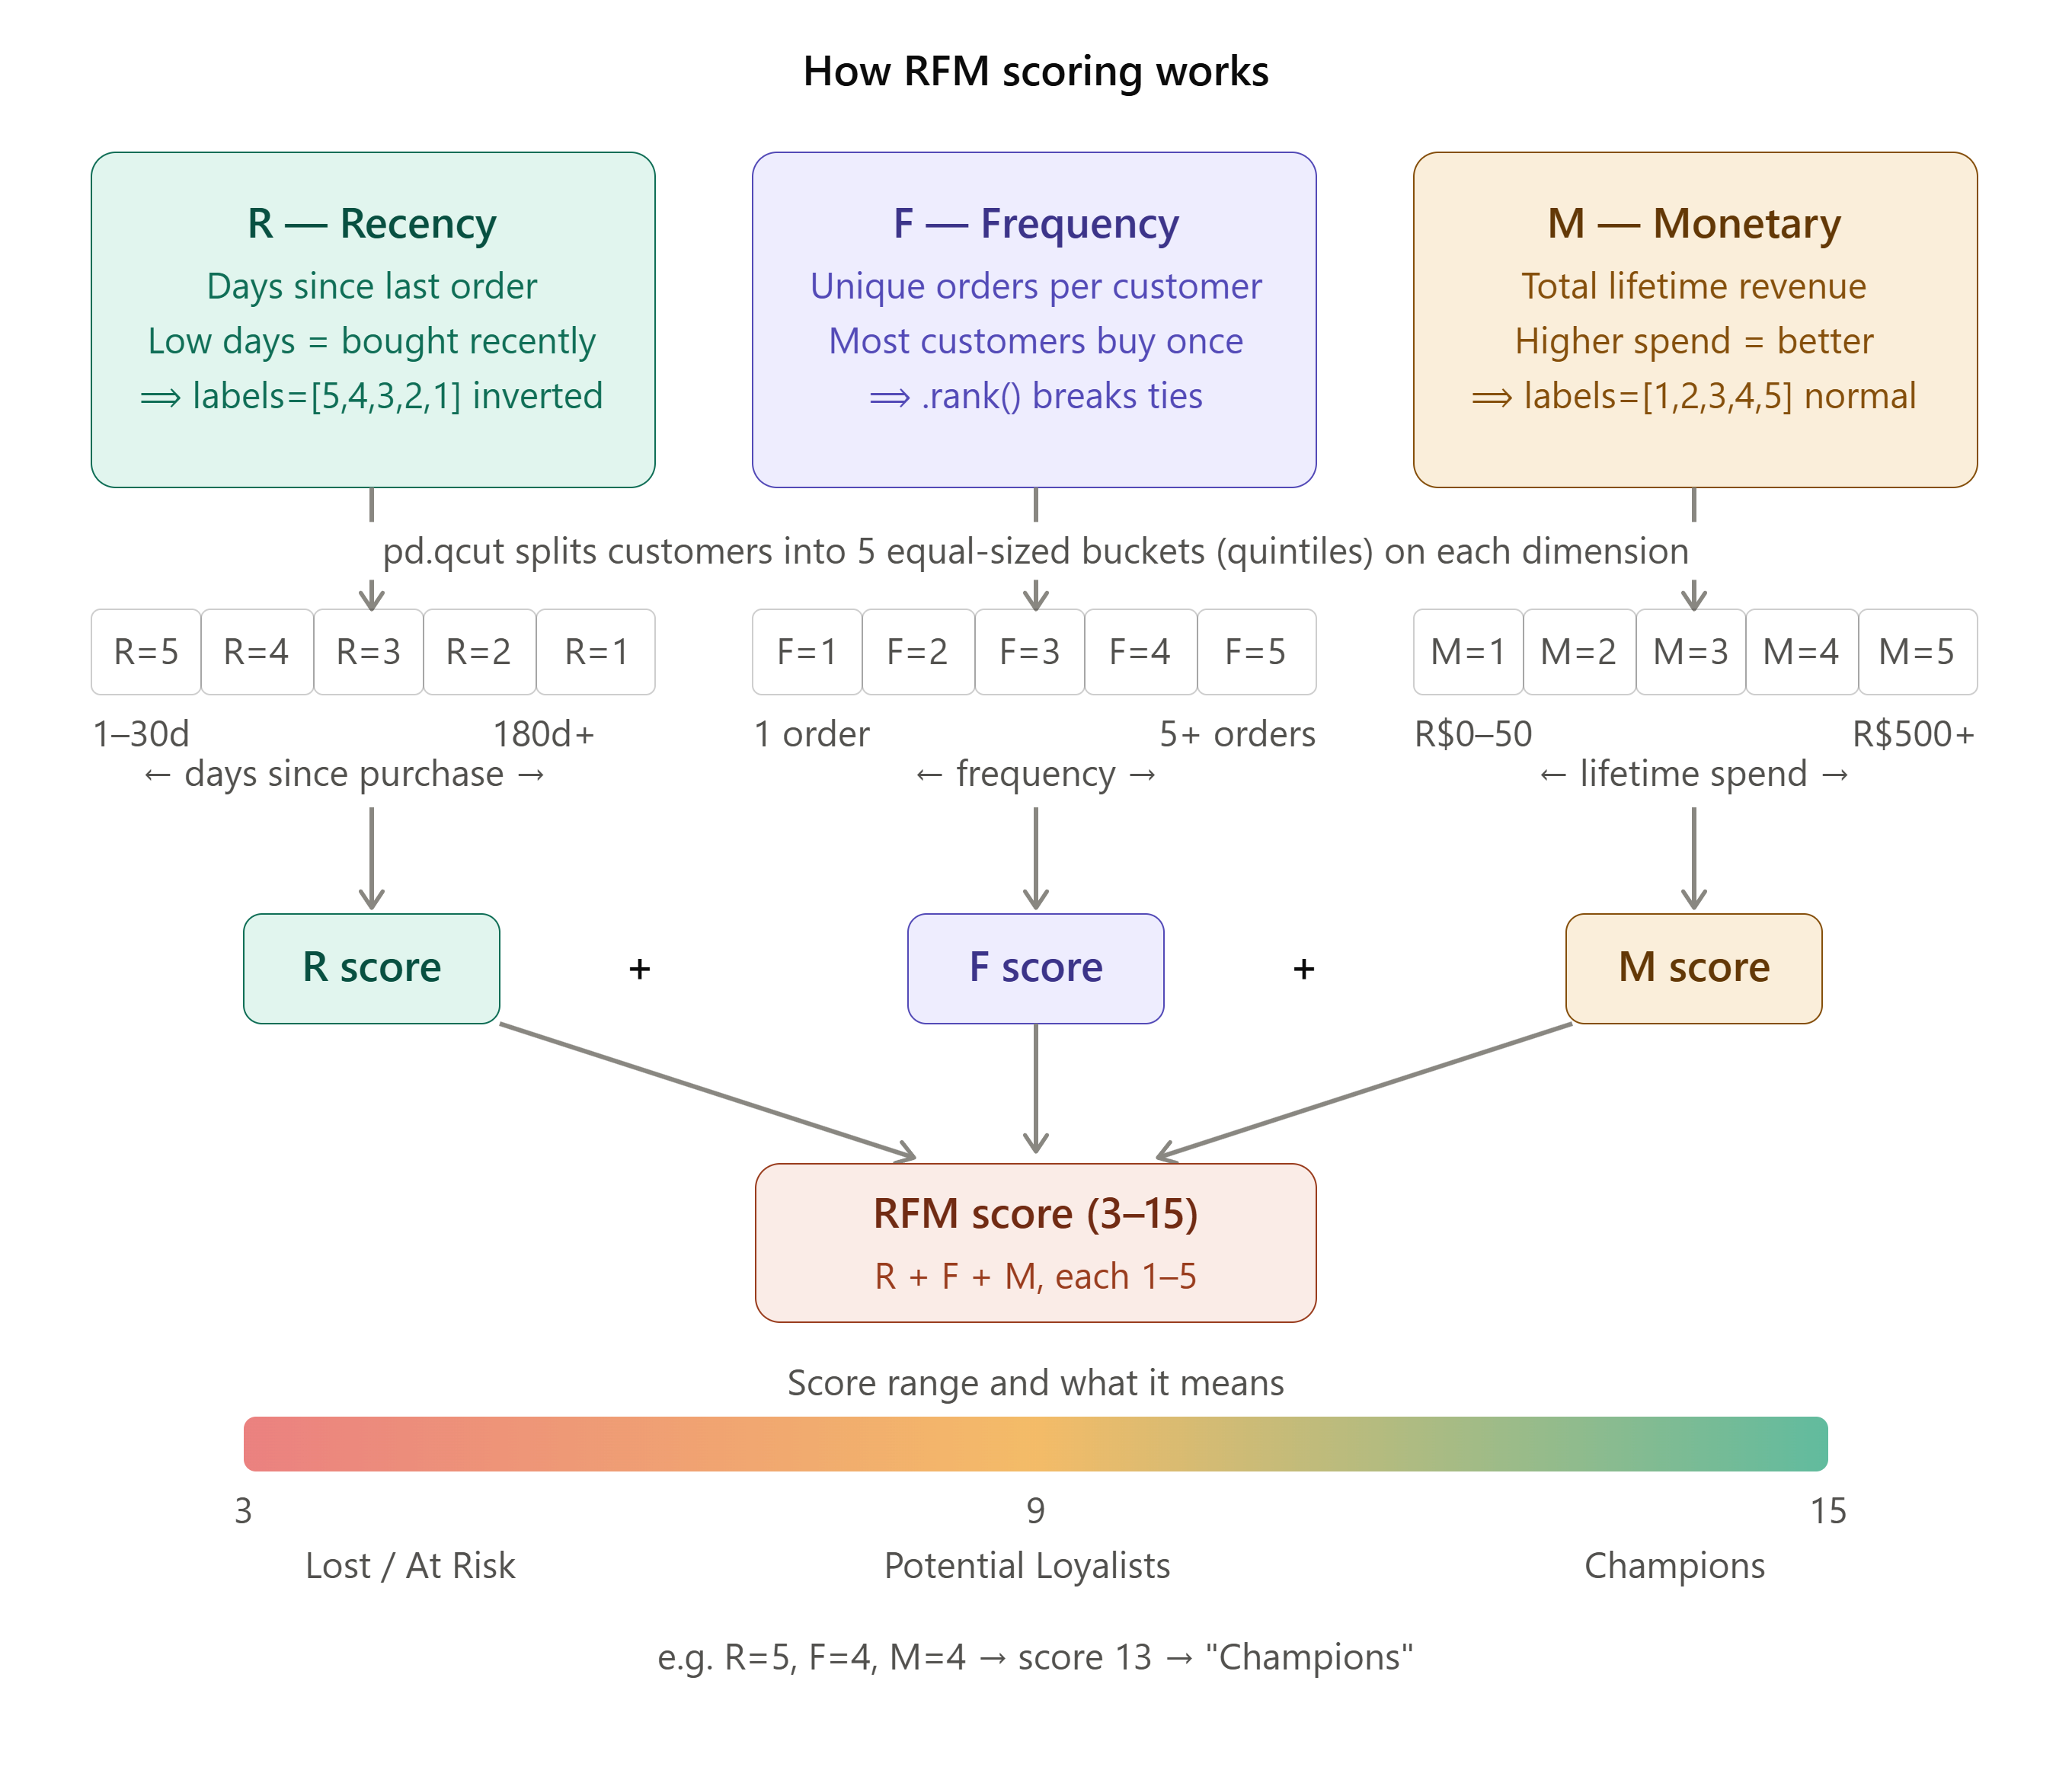

In [25]:
# Snapshot date = day after last transaction in dataset
snapshot_date = pd.to_datetime(df['order_purchase_timestamp'].max()) + pd.Timedelta(days=1)
print('Snapshot date:', snapshot_date.date())

rfm = (
    df.groupby('customer_id')
    .agg(
        recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        frequency = ('order_id', 'nunique'),
        monetary  = ('revenue', 'sum'),
    )
    .reset_index()
)

print(rfm.describe().round(2))

Snapshot date: 2018-08-30
        recency  frequency  monetary
count  96478.00    96478.0  96478.00
mean     240.12        1.0    159.83
std      152.84        0.0    218.79
min        1.00        1.0      9.59
25%      116.00        1.0     61.85
50%      221.00        1.0    105.28
75%      350.00        1.0    176.26
max      714.00        1.0  13664.08


**Why quintiles (q=5) and not deciles (q=10)?**
With ~90,000 customers, quintiles give roughly 18,000 customers per bucket per dimension — a meaningful and stable group. Deciles would create 9,000 per bucket and the segment labels become too granular to action on. Most industry RFM models use quintiles for exactly this reason.

In [30]:
# Score each dimension 1-5 using quintiles
# Recency: LOWER is better (bought recently), so we invert with ascending=False
rfm['R'] = pd.qcut(rfm['recency'],  q=5, labels=[5,4,3,2,1])  # 5 = most recent
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['monetary'], q=5, labels=[1,2,3,4,5])

rfm[['R','F','M']] = rfm[['R','F','M']].astype(int)
rfm['RFM_score'] = rfm['R'] + rfm['F'] + rfm['M']  # max=15

print('RFM score distribution:')
print(rfm['RFM_score'].value_counts().sort_index())

RFM score distribution:
RFM_score
3       790
4      2287
5      4778
6      7841
7     11558
8     13661
9     14582
10    13670
11    11570
12     7873
13     4701
14     2372
15      795
Name: count, dtype: int64


In [31]:
# Map scores to business-meaningful segments
def rfm_segment(row):
    score = row['RFM_score']
    r, f  = row['R'], row['F']
    if r >= 4 and f >= 4:   return 'Champions'
    if r >= 3 and f >= 3:   return 'Loyal Customers'
    if r >= 4 and f <= 2:   return 'Recent Customers'
    if r <= 2 and f >= 3:   return 'At Risk'
    if r == 1 and f == 1:   return 'Lost'
    return 'Potential Loyalists'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

seg_summary = (
    rfm.groupby('segment')
    .agg(
        customers = ('customer_id', 'count'),
        avg_recency  = ('recency', 'mean'),
        avg_orders   = ('frequency', 'mean'),
        avg_revenue  = ('monetary', 'mean'),
    )
    .round(1)
    .sort_values('avg_revenue', ascending=False)
)
print(seg_summary)

                     customers  avg_recency  avg_orders  avg_revenue
segment                                                             
Champions                15396         92.1         1.0        164.0
Recent Customers         15606         92.4         1.0        161.7
At Risk                  23246        397.3         1.0        160.8
Lost                      3775        474.7         1.0        158.5
Loyal Customers          19245        170.5         1.0        158.3
Potential Loyalists      19210        312.2         1.0        155.6


---
## Section 7 — Matplotlib Visualizations
> **Rule of thumb:** Matplotlib gives you control. Seaborn gives you speed. Use Matplotlib when you need pixel-perfect control for reports.

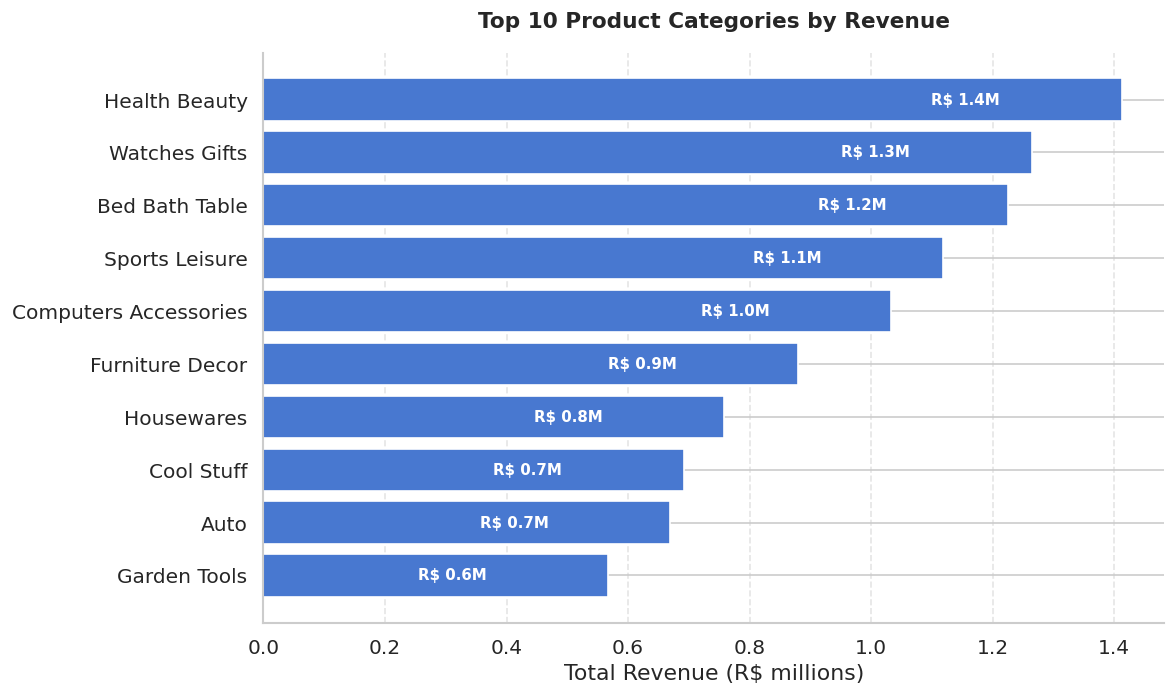

In [32]:
# --- Chart 1: Top 10 categories by revenue (horizontal bar) ---
top10 = cat_perf.head(10).sort_values('total_revenue')

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top10['category'], top10['total_revenue'] / 1e6,
               color=sns.color_palette('muted')[0], edgecolor='white')

# Add value labels inside bars
for bar in bars:
    width = bar.get_width()
    ax.text(width - 0.2, bar.get_y() + bar.get_height()/2,
            f'R$ {width:.1f}M', va='center', ha='right', color='white', fontsize=9, fontweight='bold')

ax.set_xlabel('Total Revenue (R$ millions)')
ax.set_title('Top 10 Product Categories by Revenue', fontsize=13, fontweight='bold', pad=15)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('chart_top_categories.png', bbox_inches='tight')
plt.show()

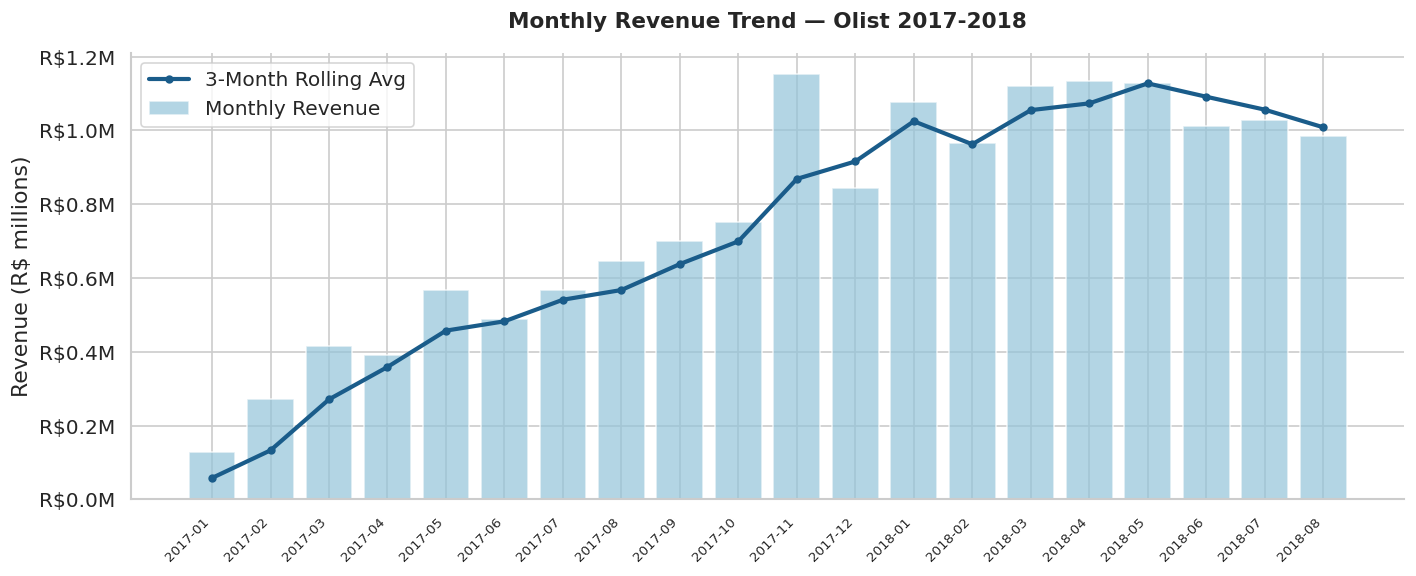

In [33]:
# --- Chart 2: Monthly revenue trend with rolling average ---
plot_df = monthly[monthly['month_str'] >= '2017-01'].copy()
x = range(len(plot_df))

fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar for monthly revenue
ax1.bar(x, plot_df['revenue']/1e6, color='#93c4d9', label='Monthly Revenue', alpha=0.7)
# Line for 3-month rolling average
ax1.plot(x, plot_df['revenue_3ma']/1e6, color='#1a5c8a', linewidth=2.5,
         marker='o', markersize=4, label='3-Month Rolling Avg')

ax1.set_xticks(list(x))
ax1.set_xticklabels(plot_df['month_str'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Revenue (R$ millions)')
ax1.set_title('Monthly Revenue Trend — Olist 2017-2018', fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='upper left')
ax1.spines[['top','right']].set_visible(False)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('R$%.1fM'))

plt.tight_layout()
plt.savefig('chart_monthly_trend.png', bbox_inches='tight')
plt.show()

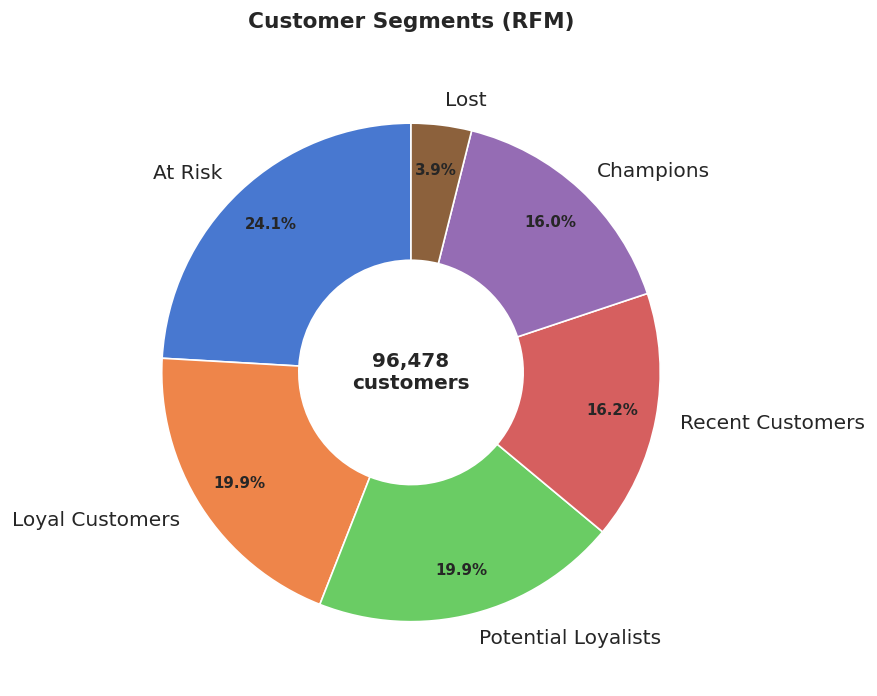

In [34]:
# --- Chart 3: Customer segment distribution (donut chart) ---
seg_counts = rfm['segment'].value_counts()
colors = sns.color_palette('muted', len(seg_counts))

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    seg_counts,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.55)    # makes it a donut
)
for t in autotexts:
    t.set_fontsize(9)
    t.set_fontweight('bold')

# Centre label
ax.text(0, 0, f"{len(rfm):,}\ncustomers", ha='center', va='center', fontsize=12, fontweight='bold')
ax.set_title('Customer Segments (RFM)', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart_segments.png', bbox_inches='tight')
plt.show()

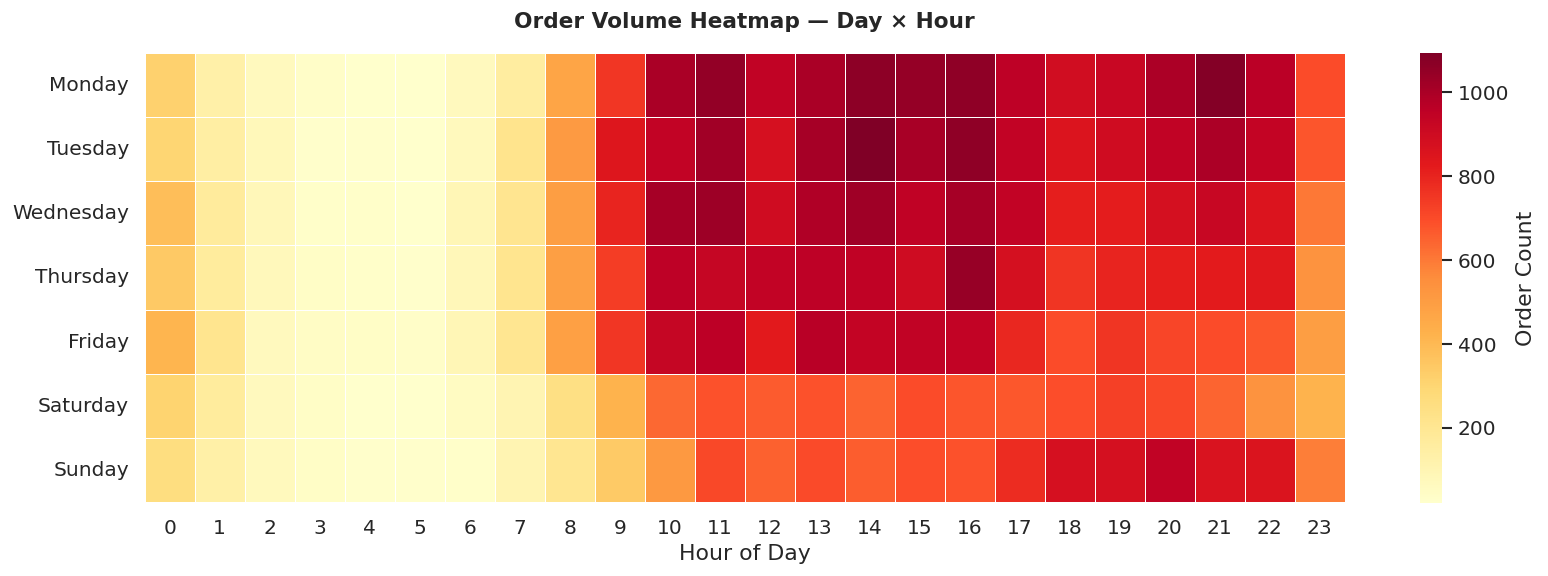

In [35]:
# --- Chart 4: Order volume heatmap — day of week × hour ---
delivered2 = delivered.copy()
delivered2['dow']  = delivered2['order_purchase_timestamp'].dt.day_name()
delivered2['hour'] = delivered2['order_purchase_timestamp'].dt.hour

heat = (
    delivered2.groupby(['dow','hour'])['order_id'].count()
    .unstack(fill_value=0)
    .reindex(dow_order)
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heat, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label':'Order Count'})
ax.set_title('Order Volume Heatmap — Day × Hour', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('chart_heatmap_dow.png', bbox_inches='tight')
plt.show()

---
## Section 8 — Seaborn Statistical Plots
> **When to use Seaborn:** Distribution analysis, correlation, and any chart where you want statistics baked in (confidence intervals, regression lines, KDE).

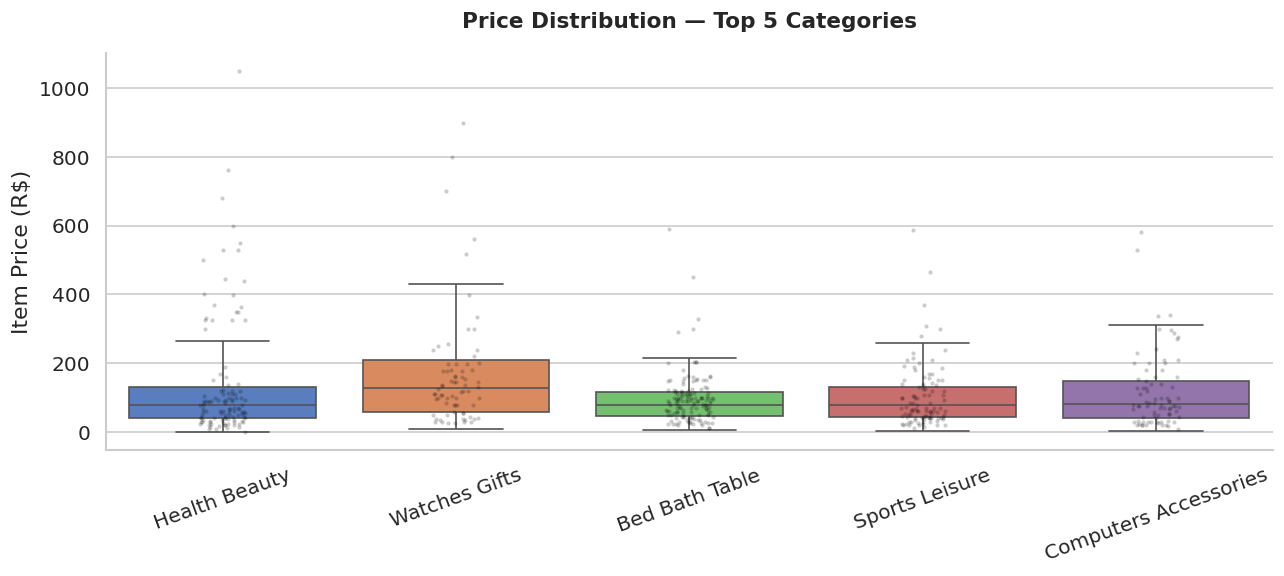

In [36]:
# --- Chart 5: Price distribution by top categories ---
top5_cats = cat_perf.head(5)['category'].tolist()
df_top5   = df[df['category'].isin(top5_cats)]

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=df_top5,
    x='category', y='price',
    palette='muted',
    order=top5_cats,
    showfliers=False,   # hide outliers for clarity
    ax=ax
)
sns.stripplot(
    data=df_top5.sample(min(500, len(df_top5)), random_state=42),
    x='category', y='price',
    order=top5_cats,
    color='black', alpha=0.2, size=2.5, ax=ax
)

ax.set_title('Price Distribution — Top 5 Categories', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Item Price (R$)')
ax.tick_params(axis='x', rotation=20)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart_price_dist.png', bbox_inches='tight')
plt.show()

**stripplot** Dataset is small-medium, you want to show every point<br>**swarmplot** Same, but you want points arranged so none overlap (slower for large data)<br>**violinplot** Large data, want smooth density shape instead of individual dots<br> **boxplot** Just want the five-number summary, don't care about individual points

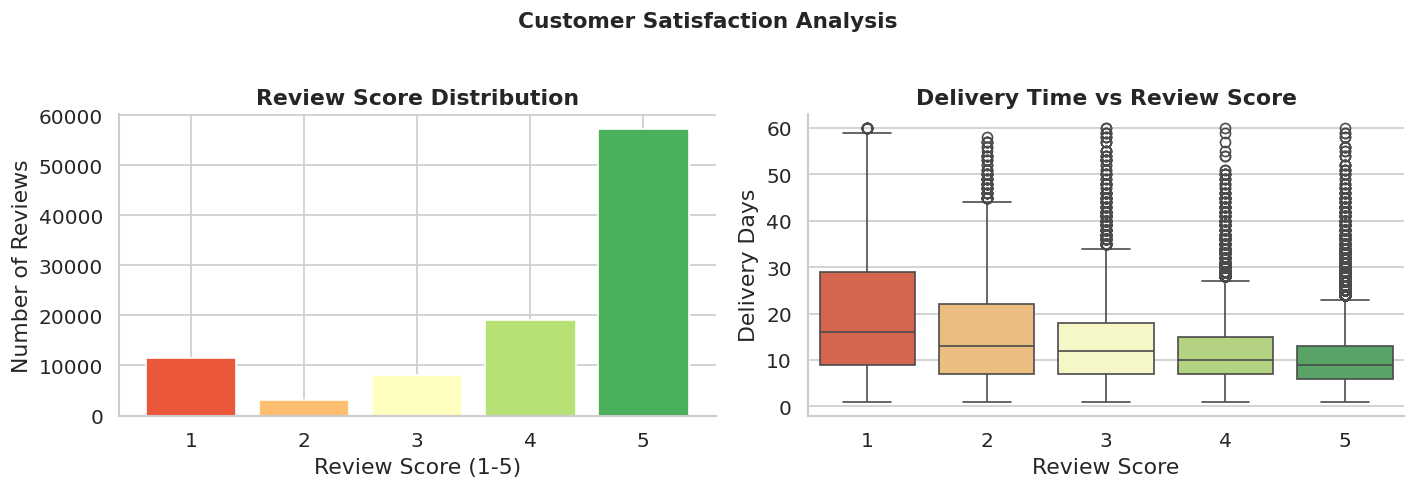

Correlation (delivery_days vs review_score): -0.334


In [37]:
# --- Chart 6: Review score distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
score_counts = reviews['review_score'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values,
            color=sns.color_palette('RdYlGn', 5), edgecolor='white')
axes[0].set_title('Review Score Distribution', fontweight='bold')
axes[0].set_xlabel('Review Score (1-5)')
axes[0].set_ylabel('Number of Reviews')
axes[0].spines[['top','right']].set_visible(False)

# Review score vs delivery days (does late delivery hurt scores?)
merged_rev = delivered.merge(reviews[['order_id','review_score']], on='order_id')
sns.boxplot(
    data=merged_rev[merged_rev['delivery_days'].between(1, 60)],
    x='review_score', y='delivery_days',
    palette='RdYlGn',
    ax=axes[1]
)
axes[1].set_title('Delivery Time vs Review Score', fontweight='bold')
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Delivery Days')
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Customer Satisfaction Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_reviews.png', bbox_inches='tight')
plt.show()

# Correlation check
corr = merged_rev['delivery_days'].corr(merged_rev['review_score'])
print(f'Correlation (delivery_days vs review_score): {corr:.3f}')

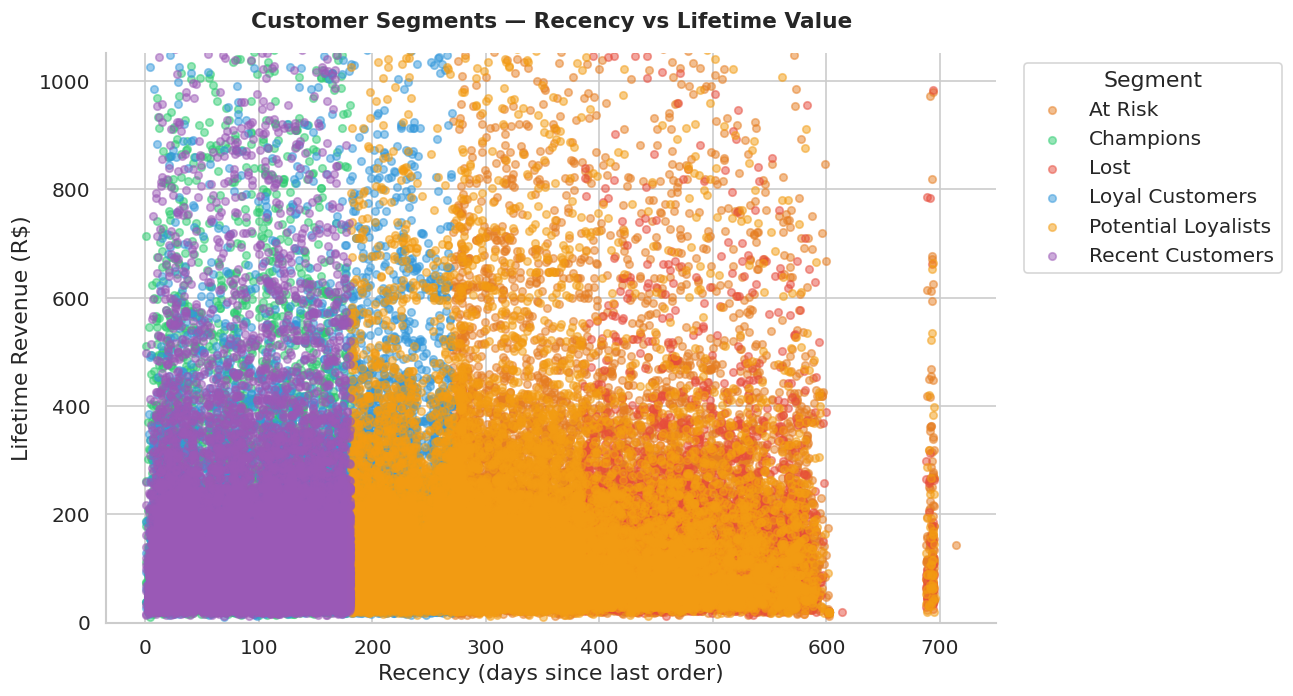

In [38]:
# --- Chart 7: RFM scatter — Recency vs Monetary coloured by segment ---
palette = {
    'Champions': '#2ecc71',
    'Loyal Customers': '#3498db',
    'Recent Customers': '#9b59b6',
    'Potential Loyalists': '#f39c12',
    'At Risk': '#e67e22',
    'Lost': '#e74c3c',
}

fig, ax = plt.subplots(figsize=(11, 6))
for seg, grp in rfm.groupby('segment'):
    ax.scatter(
        grp['recency'], grp['monetary'],
        label=seg, alpha=0.5, s=20,
        color=palette.get(seg, 'gray')
    )

ax.set_xlabel('Recency (days since last order)')
ax.set_ylabel('Lifetime Revenue (R$)')
ax.set_title('Customer Segments — Recency vs Lifetime Value', fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, rfm['monetary'].quantile(0.99))  # clip extreme outliers
ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart_rfm_scatter.png', bbox_inches='tight')
plt.show()

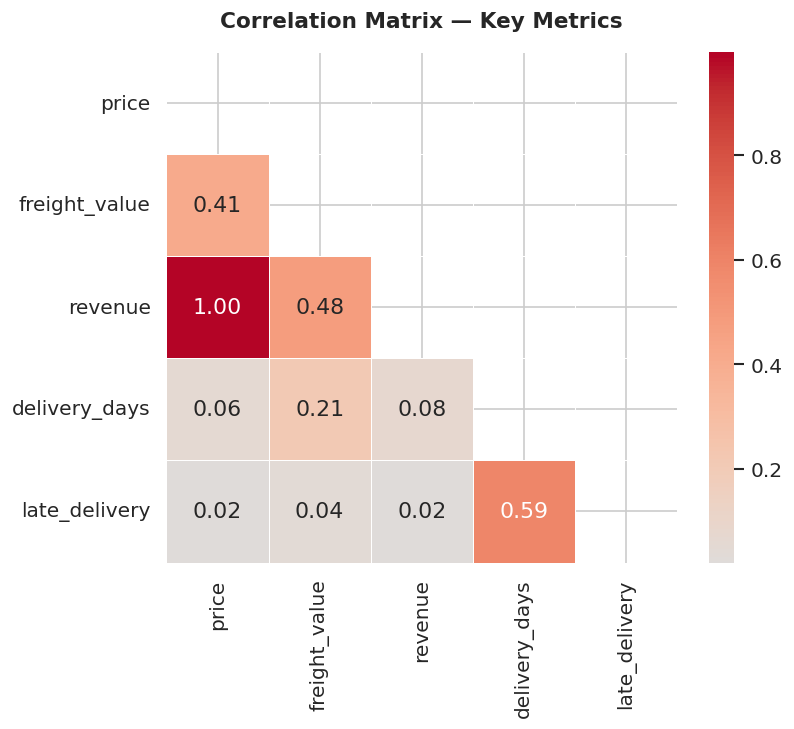

In [39]:
# --- Chart 8: Correlation heatmap of numeric KPIs ---
num_cols = ['price', 'freight_value', 'revenue', 'delivery_days', 'late_delivery']
corr_df  = df[num_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr_df, dtype=bool))  # upper triangle mask
sns.heatmap(
    corr_df, mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, square=True,
    ax=ax
)
ax.set_title('Correlation Matrix — Key Metrics', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart_correlation.png', bbox_inches='tight')
plt.show()

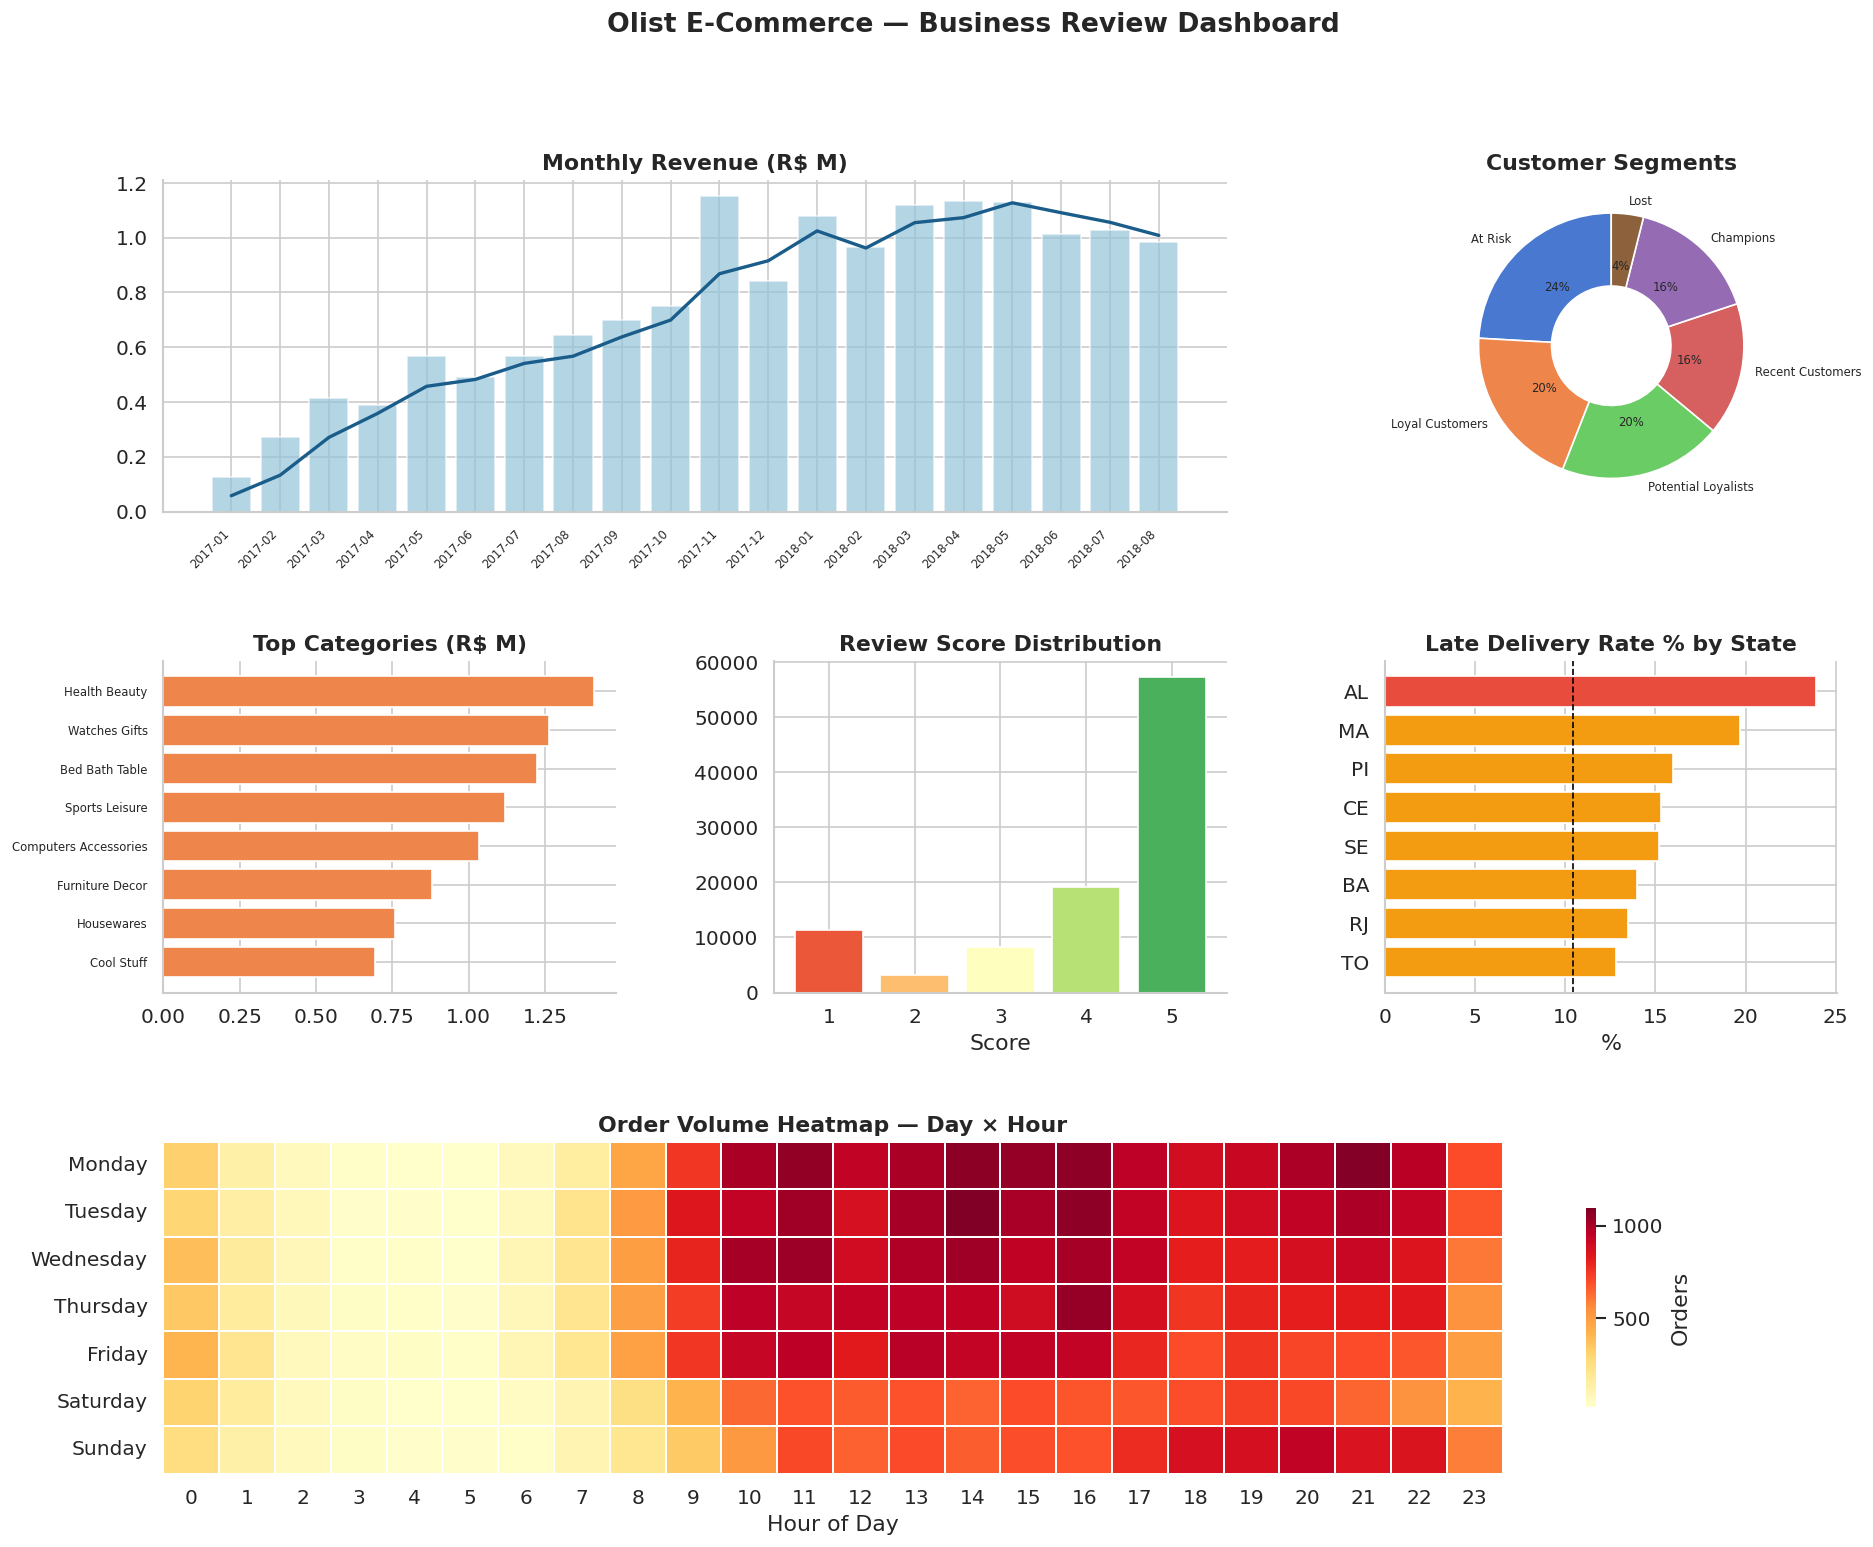

Dashboard saved as olist_business_dashboard.png


In [40]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Olist E-Commerce — Business Review Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

# Layout: 3 rows × 3 cols
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── Panel 1 (row0, col0-1): Monthly revenue ──────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
plot_df = monthly[monthly['month_str'] >= '2017-01']
x = range(len(plot_df))
ax1.bar(x, plot_df['revenue']/1e6, color='#93c4d9', alpha=0.7)
ax1.plot(x, plot_df['revenue_3ma']/1e6, color='#1a5c8a', lw=2)
ax1.set_xticks(list(x))
ax1.set_xticklabels(plot_df['month_str'], rotation=45, ha='right', fontsize=7)
ax1.set_title('Monthly Revenue (R$ M)', fontweight='bold')
ax1.spines[['top','right']].set_visible(False)

# ── Panel 2 (row0, col2): Customer segments ───────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
seg_c = rfm['segment'].value_counts()
ax2.pie(seg_c, labels=seg_c.index, autopct='%1.0f%%',
        colors=sns.color_palette('muted', len(seg_c)),
        startangle=90, wedgeprops=dict(width=0.55), textprops={'fontsize':7})
ax2.set_title('Customer Segments', fontweight='bold')

# ── Panel 3 (row1, col0): Top categories ─────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
top8 = cat_perf.head(8).sort_values('total_revenue')
ax3.barh(top8['category'], top8['total_revenue']/1e6,
         color=sns.color_palette('muted')[1])
ax3.set_title('Top Categories (R$ M)', fontweight='bold')
ax3.spines[['top','right']].set_visible(False)
ax3.tick_params(axis='y', labelsize=7)

# ── Panel 4 (row1, col1): Review score distribution ──────────────────
ax4 = fig.add_subplot(gs[1, 1])
sc = reviews['review_score'].value_counts().sort_index()
ax4.bar(sc.index, sc.values, color=sns.color_palette('RdYlGn', 5), edgecolor='white')
ax4.set_title('Review Score Distribution', fontweight='bold')
ax4.set_xlabel('Score')
ax4.spines[['top','right']].set_visible(False)

# ── Panel 5 (row1, col2): Late delivery by state (top 8) ─────────────
ax5 = fig.add_subplot(gs[1, 2])
top_late = late_by_state.head(8).sort_values('late_pct')
colors_late = ['#e74c3c' if p > 20 else '#f39c12' if p > 10 else '#2ecc71'
               for p in top_late['late_pct']]
ax5.barh(top_late.index, top_late['late_pct'], color=colors_late)
ax5.axvline(late_by_state['late_pct'].mean(), color='black', linestyle='--', lw=1)
ax5.set_title('Late Delivery Rate % by State', fontweight='bold')
ax5.set_xlabel('%')
ax5.spines[['top','right']].set_visible(False)

# ── Panel 6 (row2, full): Orders by day × hour heatmap ────────────────
ax6 = fig.add_subplot(gs[2, :])
sns.heatmap(heat, cmap='YlOrRd', ax=ax6, linewidths=0.2,
            cbar_kws={'label':'Orders', 'shrink':0.6})
ax6.set_title('Order Volume Heatmap — Day × Hour', fontweight='bold')
ax6.set_xlabel('Hour of Day')
ax6.set_ylabel('')

plt.savefig('olist_business_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('Dashboard saved as olist_business_dashboard.png')

---
## Summary — What You've Learned

| Skill | Pandas / Viz Tool | Industry Context |
|---|---|---|
| Load & inspect data | `read_csv`, `.info()`, `.describe()` | First step of every project |
| Audit missing values | `.isnull().sum()` | Data quality gate |
| Parse and derive dates | `pd.to_datetime`, `.dt.*` | Time-based KPIs |
| String cleaning | `.str.replace`, `.fillna`, `.title()` | Category normalisation |
| Multi-table joins | `.merge()` with `how=` | Replacing SQL JOINs |
| GroupBy KPIs | `.groupby().agg()` | Every business report |
| Row-level group stats | `.transform()` | Benchmarking vs peers |
| Time series & rolling | `.pct_change()`, `.rolling()` | Trend analysis |
| RFM segmentation | Custom scoring with `pd.qcut` | Marketing analytics |
| Bar, line, donut | `matplotlib` | Executive reporting |
| Box, heatmap, scatter | `seaborn` | Statistical analysis |
| Dashboard layout | `gridspec` | Full business review |

---
### Next steps for practice
1. Add a **payment method breakdown** (credit card vs boleto vs voucher)
2. Build a **seller performance** table using `olist_sellers_dataset.csv`
3. Calculate **cohort retention** — which monthly cohort has the highest repeat purchase rate?
4. Predict **late delivery** using the features you've already engineered